In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
print(os.getcwd())

C:\Users\ThinkPad


In [3]:
import os
import pandas as pd
os.chdir(r"C:\Users\ThinkPad\OneDrive\Desktop\School\School")

df=pd.read_excel("Dataset for Data Analytics.xlsx")
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    str           
 12  ReferralSource   1200 non-null   str           
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(9)


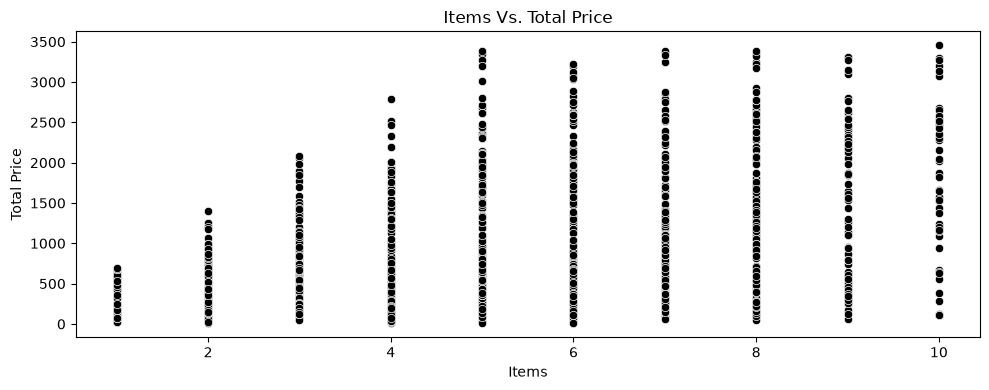

In [5]:
plt.figure(figsize=(10,4))
sns.scatterplot(x=df['ItemsInCart'], y=df['TotalPrice'], color= 'black')
plt.title('Items Vs. Total Price')
plt.xlabel('Items')
plt.ylabel('Total Price')
plt.tight_layout()
plt.show()

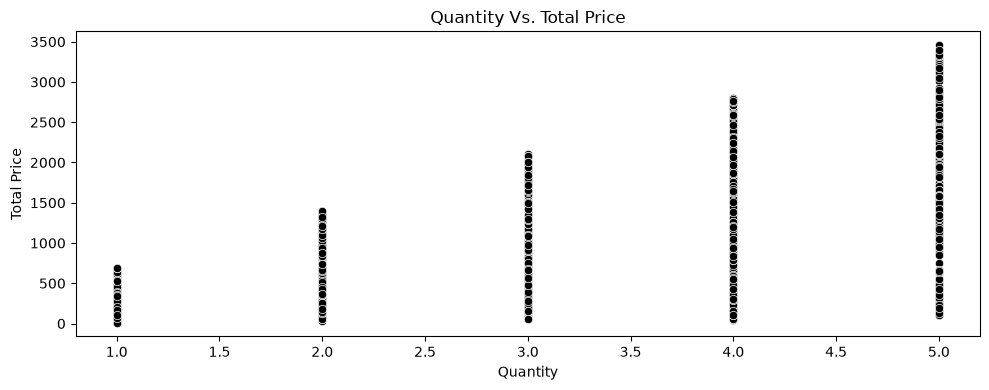

In [6]:
plt.figure(figsize=(10,4))
sns.scatterplot(x=df['Quantity'], y=df['TotalPrice'], color= 'black')
plt.title('Quantity Vs. Total Price')
plt.xlabel('Quantity')
plt.ylabel('Total Price')
plt.tight_layout()
plt.show()

In [7]:
df.describe()



,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


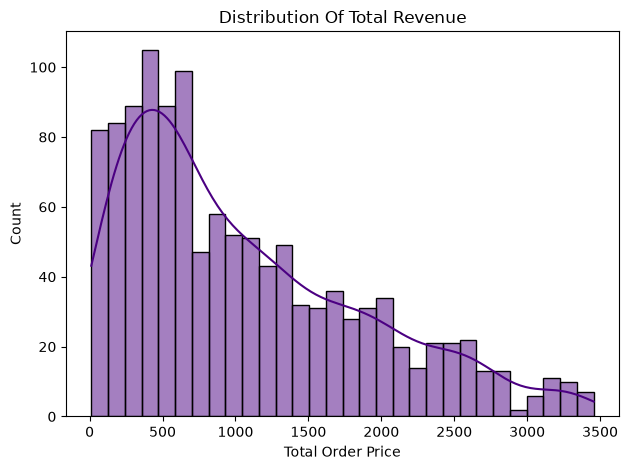

In [8]:
sns.histplot(df['TotalPrice'], kde=True, bins=30, color='indigo')
plt.title('Distribution Of Total Revenue')
plt.xlabel('Total Order Price')
plt.tight_layout()
plt.show()

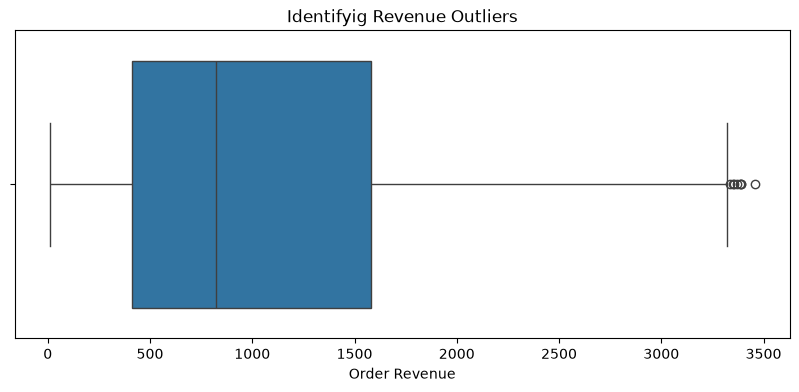

In [9]:
#Creating box plot
plt.figure(figsize=(10,4))
sns.boxplot(x=df['TotalPrice'])
plt.title('Identifyig Revenue Outliers')
plt.xlabel('Order Revenue')
plt.show()

In [10]:
Q1=df['TotalPrice'].quantile(0.25)
Q3=df['TotalPrice'].quantile(0.75)

IQR=Q3-Q1

lower_bound=Q1-1.5*IQR
upper_bound= Q3 + 1.5*IQR
df_no_outliers =df[df['TotalPrice']<= upper_bound]
print(df_no_outliers)

        OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0     ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1     ORD200001 2024-08-23     C75739    Phone         2     151.35   
2     ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3     ORD200003 2023-10-15     C33540    Chair         1     273.19   
4     ORD200004 2025-05-08     C81840  Printer         4     626.01   
...         ...        ...        ...      ...       ...        ...   
1195  ORD201195 2024-06-20     C21126     Desk         1     107.04   
1196  ORD201196 2024-03-04     C20095  Monitor         2     662.53   
1197  ORD201197 2023-07-13     C79674   Tablet         2     436.84   
1198  ORD201198 2024-08-22     C64753    Chair         4     262.52   
1199  ORD201199 2023-06-11     C57502   Tablet         4     560.58   

     ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0        928 Main St    Debit Card     Shipped    TRK37947903        

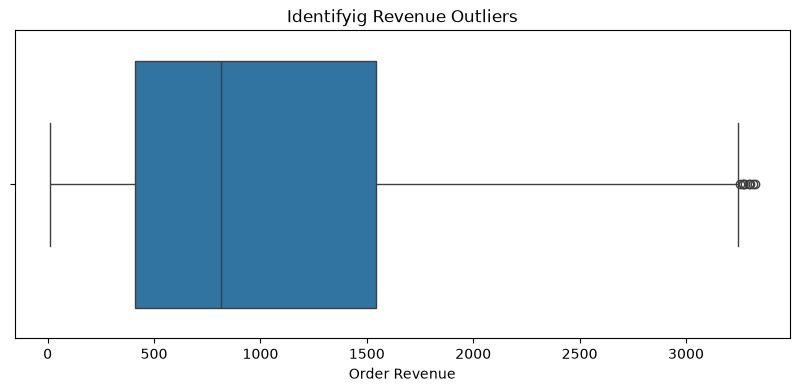

In [11]:
#Creating box plot
plt.figure(figsize=(10,4))
sns.boxplot(x=df_no_outliers['TotalPrice'])
plt.title('Identifyig Revenue Outliers')
plt.xlabel('Order Revenue')
plt.show()

In [12]:
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [13]:
df.duplicated()
df=df.drop_duplicates()

In [14]:
df['CouponCode']=df['CouponCode'].fillna(df['CouponCode'].mode()[0])
df

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,FREESHIP,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08


In [15]:
df[['Quantity','UnitPrice', 'ItemsInCart','TotalPrice']].corr()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
Quantity,1.000000,0.014553,0.650061,0.615251
UnitPrice,0.014553,1.000000,0.000602,0.717081
ItemsInCart,0.650061,0.000602,1.000000,0.392540
TotalPrice,0.615251,0.717081,0.392540,1.000000


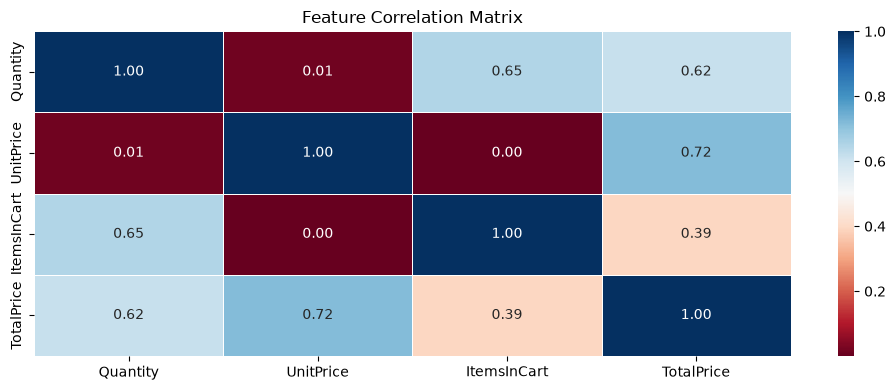

In [16]:
plt.figure(figsize=(10,4))
sns.heatmap(df[['Quantity','UnitPrice', 'ItemsInCart','TotalPrice']].corr(),
            annot=True,
            cmap="RdBu",
            fmt=".2f",
            linewidths=0.5
           )
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_34220\4224977988.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df, x='OrderStatus', palette='Blues_r')


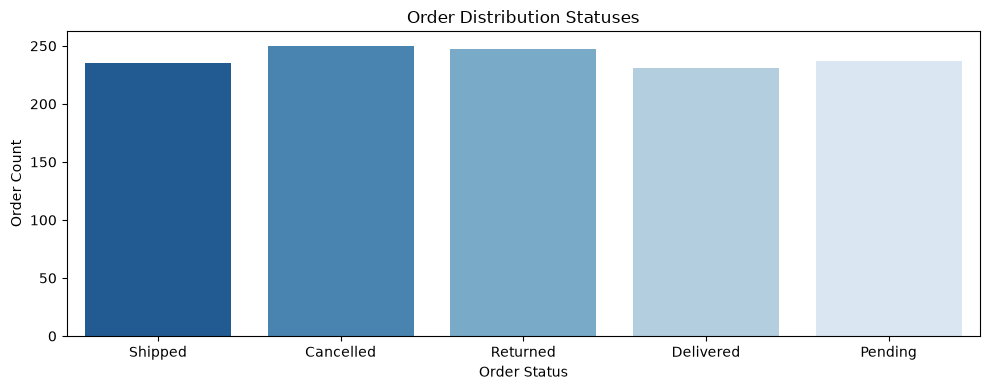

In [21]:
plt.figure(figsize=(10,4))
sns.countplot(df, x='OrderStatus', palette='Blues_r')
plt.title('Order Distribution Statuses')
plt.xlabel('Order Status')
plt.ylabel('Order Count')
plt.tight_layout()
plt.show()

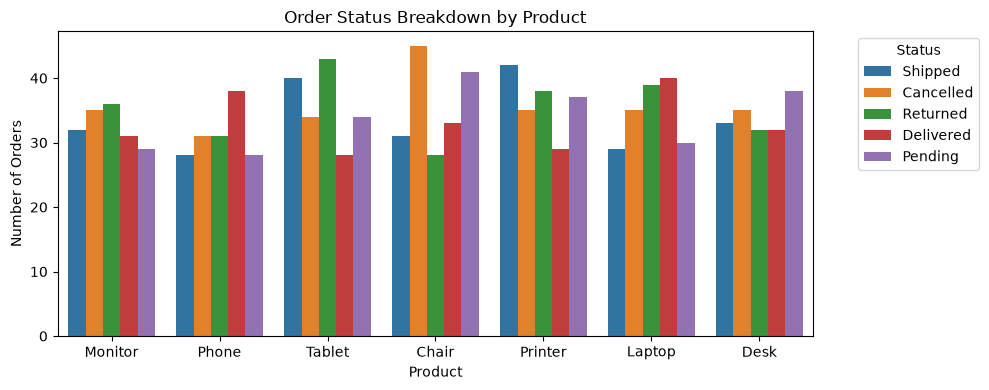

In [23]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='Product', hue='OrderStatus')
plt.title('Order Status Breakdown by Product')
plt.xlabel('Product')
plt.ylabel('Number of Orders')
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Key Takeaway: Revenue Distribution & Outliers
* **Skewness:** The `TotalPrice` distribution is moderately right-skewed (+0.89), with the average order value ($1,053.97) sitting higher than the median ($823.62).
* **Outlier Behavior:** Using the 1.5x IQR method, 8 transactions exceeded the upper threshold of $3,330.41. 
* **Business Insight:** These 8 orders represent legitimate bulk purchases (5 units of high-cost hardware like Laptops and Printers) rather than recording errors, so they are retained in the primary dataset.